<a href="https://colab.research.google.com/github/ahamasmi-yoddhaha/ml_practice/blob/main/mlpractice1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('insurance.csv')
#output variable=charges
#insurance charges are nothing but the insurance claim

In [ ]:
df


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


**EDA**

In [ ]:
df.shape #DATA VIEWING

(1338, 7)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info() #DATA VIEWING

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe() #SUMMARY STATISTICS
#only numeric type colums are considered

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum() #MISSING VALUE ANALYSIS
#to check if the data contains any null values

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.columns
#prints all features

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

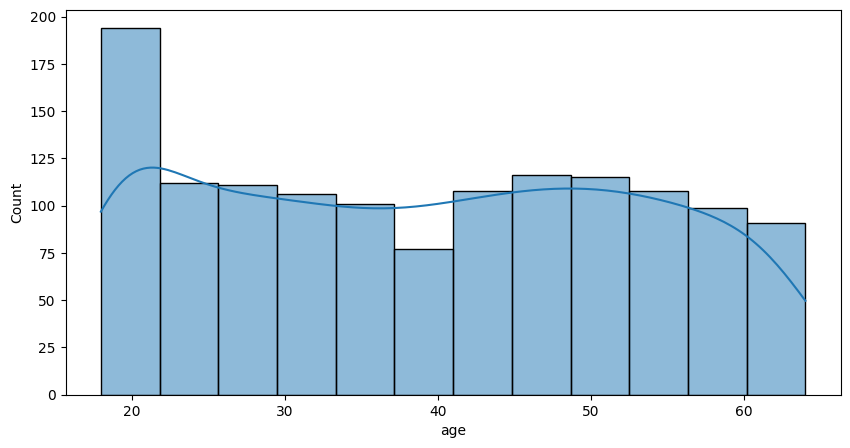

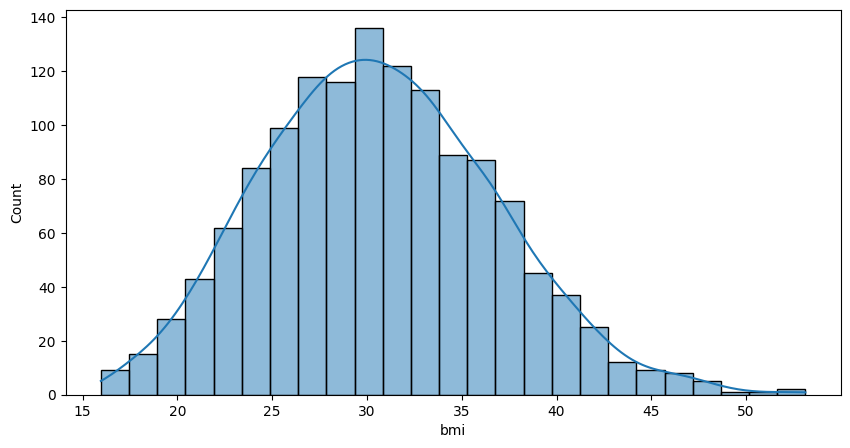

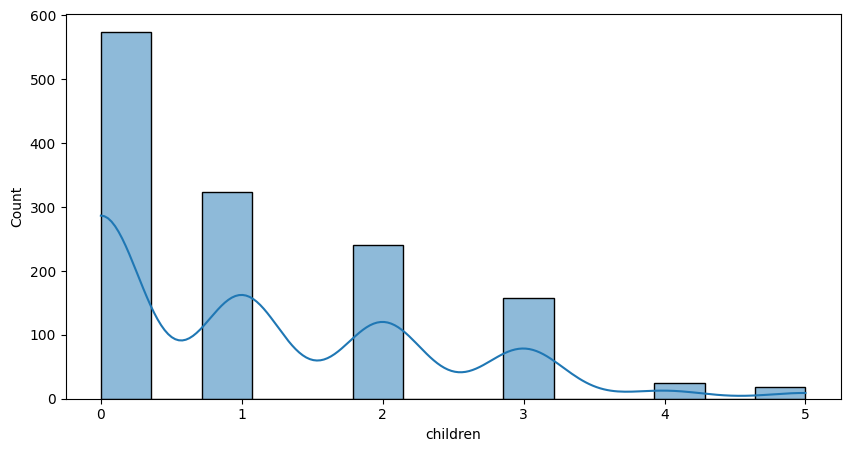

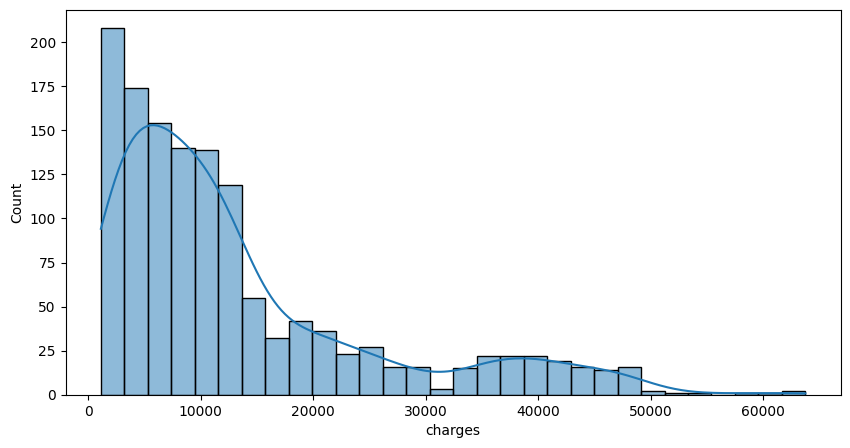

In [ ]:
numeric_col=['age', 'bmi', 'children', 'charges'] #numeric_col is a list which contains all numeric type columns which is used for visualisation
for x in numeric_col:
  plt.figure(figsize=(10,5)) #figsize=(10,5) represents the pixels
  sns.histplot(df[x],kde=True) #histogram plot for seeing the distribution, kde=kernal desity estimation, gives the curve

*Observations from the histogram plots:*
1. people from age <=20 are comparatively more in number, rest all equally distributed.
2. bmi is in normal distribution, implies that the bmis are rightly taken.
3. no.of children can be 1,2,3,4,5 and its just gives how many people have how many children, it doesn't have much use in here. Children here is acting like a categorical variable so no use case here.
4. generally, if age is more then insurance charges are higher and vice-versa, since we have younger people more in the data set, there are more number of people whose charges are less, right skewed distribution

<Axes: xlabel='children', ylabel='count'>

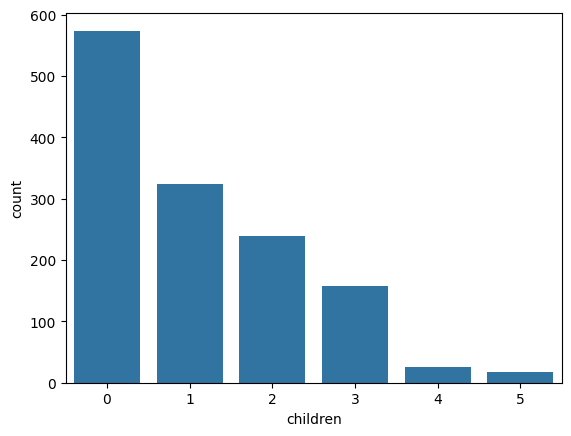

In [ ]:
#creating a count plots for all the other types of columns now
sns.countplot(x=df['children']) #x axis is children

there is a possibility that if people have 0 number of children then there is a chance that their insurance charges are less

<Axes: xlabel='sex', ylabel='count'>

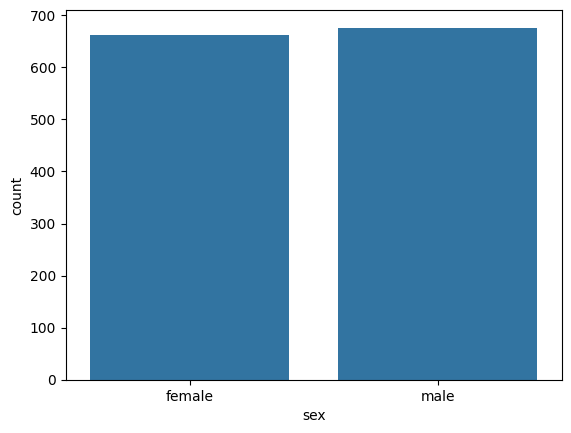

In [ ]:
sns.countplot(x=df['sex'])

there is no much difference in male and female

<Axes: xlabel='smoker', ylabel='count'>

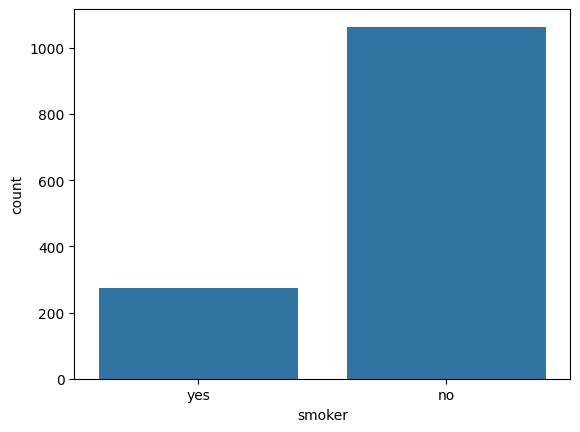

In [ ]:
sns.countplot(x=df['smoker'])

there is a chance that young, non smokers will get less charges

until now, inputs are separately analysed, now they will be analysed along with the output variable

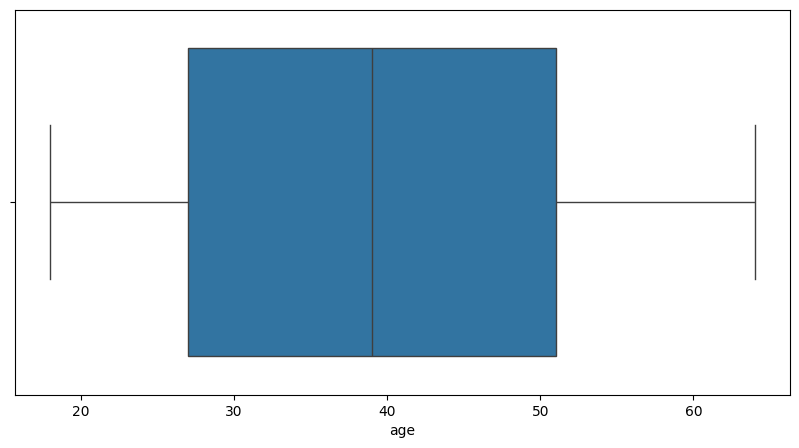

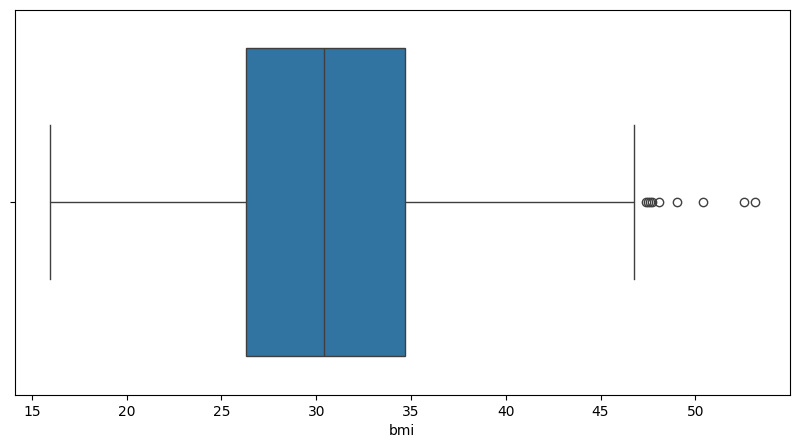

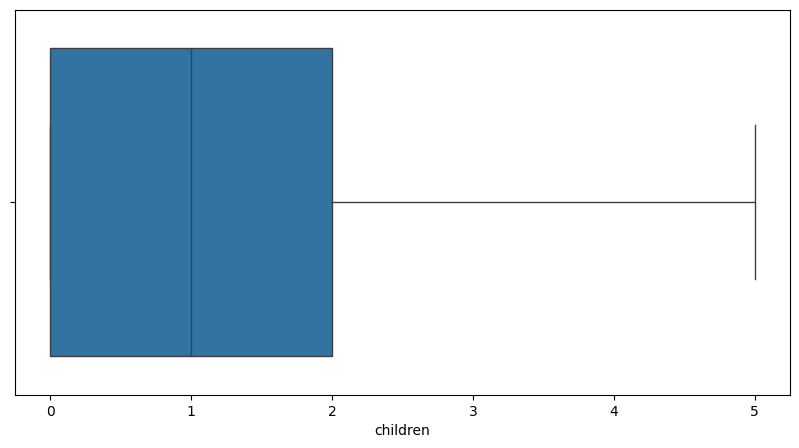

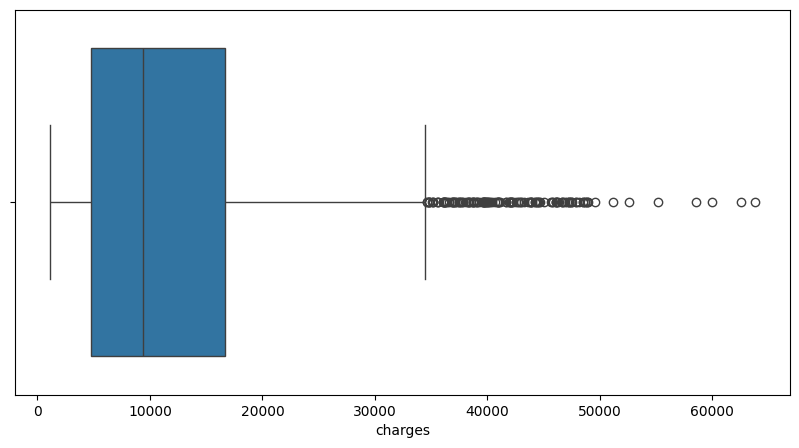

In [ ]:
for x in numeric_col:
  plt.figure(figsize=(10,5))
  sns.boxplot(x=df[x])  #used for knowing the outliers

Observations from the box plots:
1. no outliers, equally distributed but a little inclined towards left because people <=20 are more
2. bmi showed normal distribution but still has outliers, lets see if we have to keep them or remove them
3. most of the people have 0 children so it is completely on left
4. coming to charges, most points were on the left so box plot is created on the left side but all the remaining values near the skew are all taken as outliers here

<Axes: >

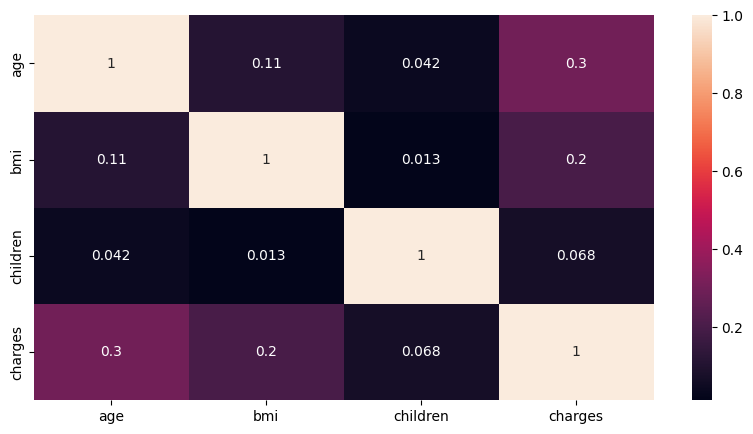

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True) #correlations are best shown via heatmaps
#correlations are shown for numeric values only
#annot=true gives the values also

*Observations made from heatmap:*
1. age and charges are highly correlated
2. children and ages are the least correlated
3. children and charges are less correlated too
4. we may remove the children feature

**Data Cleaning and Preprocessing**

if data contains null values then use suitable technique and fill up the missing values accordingly (use internet/resources/ai)

here data doesn't contain any null values

In [ ]:
df_cleaned=df.copy()

In [ ]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(1338, 7)

one duplicate was found and dropped(deleted)

In [ ]:
df_cleaned.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
#now we have to change all the columns to numeric types
df_cleaned['sex'].value_counts()

,count
sex,
male,676
female,662


In [ ]:
df_cleaned['sex']=df_cleaned['sex'].map({"male":0,"female":1}) #label encoding

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [ ]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


In [ ]:
df_cleaned['smoker']=df_cleaned['smoker'].map({"no":0,"yes":1}) #label encoding

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [ ]:
df_cleaned.rename(columns={'sex':'is_female','smoker':'is_smoker'},inplace=True)

In [ ]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [ ]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [ ]:
#one hot encoding
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [ ]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'])

In [ ]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False


In [ ]:
df_cleaned=df_cleaned.astype(int)

In [ ]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


**Feature Engineering & Extraction**

<Axes: xlabel='bmi', ylabel='Count'>

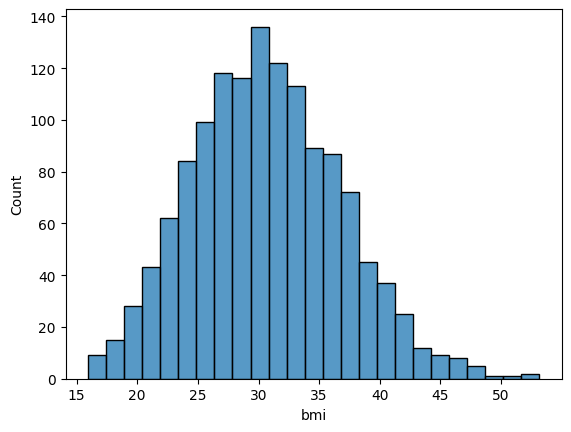

In [ ]:
sns.histplot(df['bmi'])

In [ ]:
#research why we are cutting here
df_cleaned['bmi_category']=pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['underweight','healthy','overweight','obese']
)
